# Machine Learning Work

In [514]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import KFold, train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    root_mean_squared_error,
    r2_score,
    mean_absolute_error,
    mean_squared_error,
)
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RandomizedSearchCV

In [515]:
RANDOM_SEED = 42
TEST_RATIO = 0.2
DATA_BASE_PATH = Path("../data")  # uma pasta acima de 'rent'
POI_DATA_BASE_PATH = Path("poi-data")  # estamos dentro de 'rent'
TARGET = "price"

In [516]:
rent_path = DATA_BASE_PATH / "apartments_for_rent_classified_10K.csv"
poi_count_path = (
    POI_DATA_BASE_PATH / "poi-data-count-5d44b231d67f516b837067ff178d5c01.parquet"
)

In [517]:
rent = pd.read_csv(rent_path, sep=";", encoding="latin1", dtype={"id": str})
rent.head()

,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,...,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
0,5668626895,housing/rent/apartment,"Studio apartment 2nd St NE, Uhland Terrace NE,...","This unit is located at second St NE, Uhland T...",NaN,NaN,0.0,USD,No,Thumbnail,...,$790,Monthly,101,NaN,Washington,DC,38.9057,-76.9861,RentLingo,1577359415
1,5664597177,housing/rent/apartment,Studio apartment 814 Schutte Road,"This unit is located at 814 Schutte Road, Evan...",NaN,NaN,1.0,USD,No,Thumbnail,...,$425,Monthly,106,814 Schutte Rd,Evansville,IN,37.9680,-87.6621,RentLingo,1577017063
2,5668626833,housing/rent/apartment,"Studio apartment N Scott St, 14th St N, Arling...","This unit is located at N Scott St, 14th St N,...",NaN,1.0,0.0,USD,No,Thumbnail,...,"$1,390",Monthly,107,NaN,Arlington,VA,38.8910,-77.0816,RentLingo,1577359410
3,5659918074,housing/rent/apartment,Studio apartment 1717 12th Ave,"This unit is located at 1717 12th Ave, Seattle...",NaN,1.0,0.0,USD,No,Thumbnail,...,$925,Monthly,116,1717 12th Avenue,Seattle,WA,47.6160,-122.3275,RentLingo,1576667743
4,5668626759,housing/rent/apartment,"Studio apartment Washington Blvd, N Cleveland ...","This unit is located at Washington Blvd, N Cle...",NaN,NaN,0.0,USD,No,Thumbnail,...,$880,Monthly,125,NaN,Arlington,VA,38.8738,-77.1055,RentLingo,1577359401


In [518]:
rent.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             10000 non-null  object 
 1   category       10000 non-null  object 
 2   title          10000 non-null  object 
 3   body           10000 non-null  object 
 4   amenities      6451 non-null   object 
 5   bathrooms      9966 non-null   float64
 6   bedrooms       9993 non-null   float64
 7   currency       10000 non-null  object 
 8   fee            10000 non-null  object 
 9   has_photo      10000 non-null  object 
 10  pets_allowed   5837 non-null   object 
 11  price          10000 non-null  int64  
 12  price_display  10000 non-null  object 
 13  price_type     10000 non-null  object 
 14  square_feet    10000 non-null  int64  
 15  address        6673 non-null   object 
 16  cityname       9923 non-null   object 
 17  state          9923 non-null   object 
 18  latitud

## Data Cleaning

In this part of the notebook, we will clean the data. We will remove any unnecessary columns, handle missing values, and ensure that the data is in a format suitable for further analysis.

### Drop unnecessary columns

In [519]:
"""
features_to_drop is a list of columns that are not useful for the model.
The reason for dropping each column is one of the following:
- R1: Irrelevant: the column is not relevant to the model.
- R2: Redundant: the column is redundant with another column.
- R3: Need more features: the column needs more features to be useful.
- R4: Biased: the column is biased on the source.
- R6: Not useful: the column is not useful to predict the price of the property rent itself.
- R7: Unique value: the column has only one unique value.
- R8: Too many unique values: the column has too many unique values to be useful.
"""
features_to_drop = [
    # "id",  # R1: Irrelevant
    "time",  # R1: Irrelevant
    "source",  # R4: Biased
    "latitude",  # R3: Need more features to relate the location to the price
    "longitude",  # R3: Need more features to relate the location to the price
    "price_display",  # R2: Redundant with the price column
    "has_photo",  # R6: Not useful
    "fee",  # R7: Unique value
    "currency",  # R7: Unique value
    "address",  # R3: Need more features to relate the location to the price
    "cityname",  # R8: Low cardinality
    "body",  # R1: Irrelevant
    "title",  # R1: Irrelevant
]

rent.drop(columns=features_to_drop, inplace=True)
rent

,id,category,amenities,bathrooms,bedrooms,pets_allowed,price,price_type,square_feet,state
0,5668626895,housing/rent/apartment,NaN,NaN,0.0,NaN,790,Monthly,101,DC
1,5664597177,housing/rent/apartment,NaN,NaN,1.0,NaN,425,Monthly,106,IN
2,5668626833,housing/rent/apartment,NaN,1.0,0.0,NaN,1390,Monthly,107,VA
3,5659918074,housing/rent/apartment,NaN,1.0,0.0,NaN,925,Monthly,116,WA
4,5668626759,housing/rent/apartment,NaN,NaN,0.0,NaN,880,Monthly,125,VA
...,...,...,...,...,...,...,...,...,...,...
9995,5630240092,housing/rent/apartment,NaN,4.0,5.0,NaN,6000,Monthly,6300,MN
9996,5668640983,housing/rent/apartment,NaN,8.0,6.0,NaN,25000,Monthly,8716,CA
9997,5668643292,housing/rent/apartment,NaN,8.5,6.0,NaN,11000,Monthly,11318,MD
9998,5668662559,housing/rent/apartment,"Basketball,Cable or Satellite,Doorman,Hot Tub,...",NaN,1.0,NaN,4790,Monthly,40000,NY


### Drop rows with missing values

In [520]:
post_processing_features = [
    TARGET,  # target variable
    "pets_allowed",  # will be one-hot encoded
    "amenities",  # will have nlp processing
]

dropna_cols = set(rent.columns) - set(post_processing_features)

rent = rent.dropna(subset=dropna_cols)
rent.shape

(9883, 10)

In [521]:
def filter_column(df: pd.DataFrame, column: str, filter_value: str) -> pd.DataFrame:
    """
    Filter a dataframe by a column and a value.
    """
    df = df.loc[df[column] == filter_value]
    if df.empty:
        raise ValueError(f"Column {column} has no values for {filter_value}")
    return df

In [522]:
rent = filter_column(rent, "price_type", "Monthly")  # Few rows with other values (< 1%)
rent = rent.drop(columns=["price_type"])
rent.shape

(9882, 9)

In [523]:
rent = filter_column(
    rent, "category", "housing/rent/apartment"
)  # Few rows with other values (< 1%)
rent = rent.drop(columns=["category"])
rent.shape

(9879, 8)

In [524]:
# Removing states with one row
state_counts = rent["state"].value_counts()
rent = rent.loc[rent["state"].isin(state_counts[state_counts > 1].index)]
rent["state"].value_counts()

state
TX    1729
CA     950
WA     519
NC     437
MD     422
NJ     383
GA     370
FL     338
OH     320
CO     317
WI     302
IL     280
MO     238
IN     237
MN     221
VA     204
OR     197
PA     182
IA     179
OK     178
MI     176
MA     166
AZ     123
NV     121
ND     112
NE     105
CT      98
TN      91
UT      84
KS      83
SC      77
DC      73
NH      70
NY      68
SD      66
LA      66
AL      56
AR      56
AK      44
KY      40
ID      21
VT      16
NM      14
HI      12
RI      11
MS       9
MT       7
DE       5
WV       3
ME       2
Name: count, dtype: int64

### Remove outliers

In [525]:
def iqr_outlier_bounds(series: pd.Series) -> tuple[float, float]:
    """
    Calculate the IQR outlier bounds for a given series.
    The function returns a tuple with the lower and upper bounds.
    """
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return lower_bound, upper_bound


def detect_outliers(df: pd.DataFrame) -> pd.DataFrame:
    """
    Detect outliers in the dataframe.
    The function uses the IQR method to detect outliers.
    The function returns a dataframe with the following columns:
    - column: the name of the column
    - lower_bound: the lower bound of the IQR
    - upper_bound: the upper bound of the IQR
    - outliers_percentage: the percentage of outliers in the column
    The function only considers columns with numeric data types (float64 and int64).
    The function returns an empty dataframe if there are no outliers.
    """
    detected_outliers: list[dict] = []
    for col in df.select_dtypes(include=["float64", "int64"]).columns:
        lower_bound, upper_bound = iqr_outlier_bounds(df[col])
        outlier_mask = ~df[col].between(lower_bound, upper_bound)
        if outlier_mask.empty:
            continue
        outlier_percentage = outlier_mask.sum() / len(df[col]) * 100
        detected_outliers.append(
            {
                "column": col,
                "lower_bound": lower_bound,
                "upper_bound": upper_bound,
                "outliers_percentage": outlier_percentage,
                "count": outlier_mask.sum(),
            }
        )
    return pd.DataFrame(detected_outliers)

In [526]:
def show_boxplot(
    df: pd.DataFrame, columns: str | list[str], title: str, log_scale: bool = False
) -> None:
    """
    Show a boxplot of the given columns in the dataframe.
    The function takes the following parameters:
    - df: the dataframe to plot
    - columns: the columns to plot
    - title: the title of the plot
    - log_scale: whether to use a log scale for the x-axis
    """
    plt.figure(figsize=(8, len(columns) / 2))
    plt.title(title)
    if isinstance(columns, str):
        columns = [columns]
    data = [df[col].dropna() for col in columns]
    plt.boxplot(data, vert=False, tick_labels=columns)
    if log_scale:
        plt.xscale("log")
    plt.xlabel("Values")
    plt.ylabel("Features")
    plt.yticks(rotation=45)  # Rotate the label names
    plt.tight_layout()
    plt.show()

In [527]:
detected_outliers = detect_outliers(rent)
outliers_columns = detected_outliers["column"].tolist()

detected_outliers.sort_values(by="outliers_percentage", ascending=False)

,column,lower_bound,upper_bound,outliers_percentage,count
3,square_feet,-25.0,1775.0,6.236080,616
2,price,-170.0,2814.0,6.165216,609
1,bedrooms,-0.5,3.5,5.162988,510
0,bathrooms,-0.5,3.5,0.728892,72


In [528]:
detected_outliers["count"].sum()

np.int64(1807)

In [529]:
rent[outliers_columns].describe()

,bathrooms,bedrooms,price,square_feet
count,9878.000000,9878.000000,9878.000000,9878.000000
mean,1.380543,1.747014,1487.315246,943.331545
std,0.616095,0.941801,1078.738745,527.227418
min,1.000000,0.000000,200.000000,107.000000
25%,1.000000,1.000000,949.000000,650.000000
50%,1.000000,2.000000,1275.000000,803.000000
75%,2.000000,2.000000,1695.000000,1100.000000
max,8.500000,9.000000,52500.000000,11318.000000


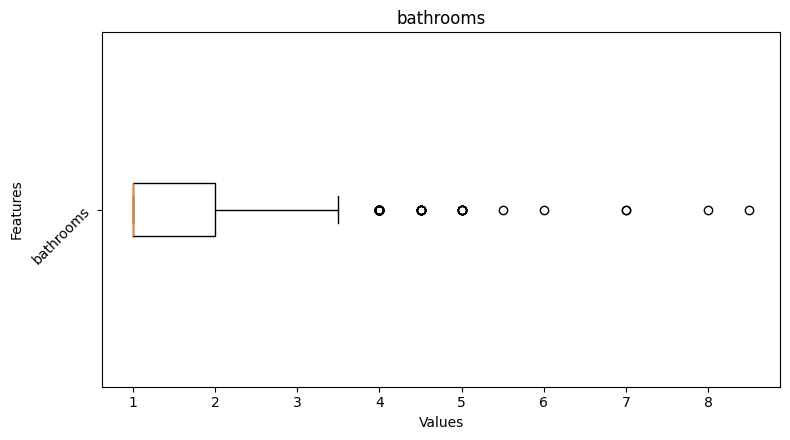

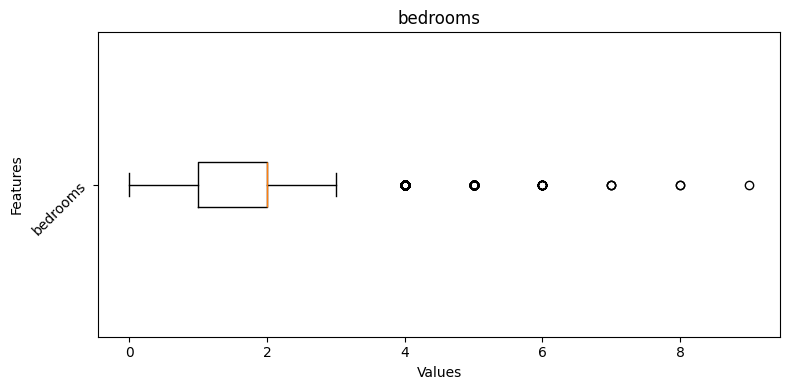

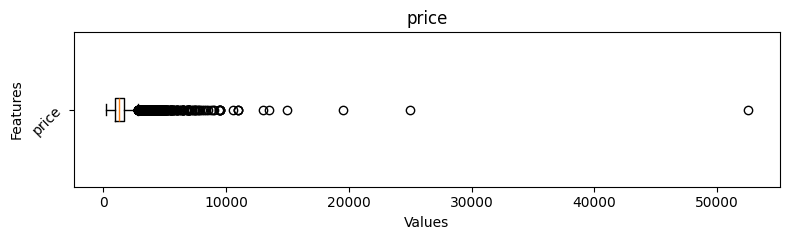

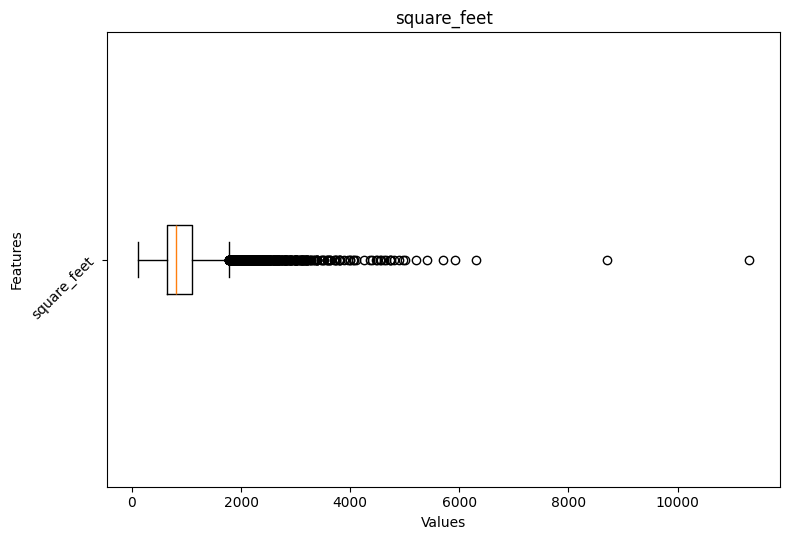

In [530]:
for col in outliers_columns:
    show_boxplot(rent, col, col)

In [531]:
def remove_outliers(
    df: pd.DataFrame, column: str, lower_bound: float, upper_bound: float
) -> pd.DataFrame:
    """
    Remove outliers from the dataframe.
    The function uses the IQR method to detect outliers.
    """
    return df[df[column].between(lower_bound, upper_bound)]

In [532]:
rent.shape

(9878, 8)

In [533]:
for col in outliers_columns:
    lower_bound, upper_bound = iqr_outlier_bounds(rent[col])
    rent = remove_outliers(rent, col, lower_bound, upper_bound)

rent = rent.reset_index(drop=True)
rent.shape

(8489, 8)

### Convert categorical variables to numerical

In [534]:
def one_hot_encode_column(
    df: pd.DataFrame, column: str, drop_first: bool = False
) -> pd.DataFrame:
    """
    One-hot encode a given column in the dataframe.
    The function returns the dataframe with the one-hot encoded column.
    """
    df = df.copy()
    encoder = OneHotEncoder(
        sparse_output=False,
        drop="first" if drop_first else None,
        handle_unknown="ignore",
    )
    encoded_column = encoder.fit_transform(df[[column]])
    encoded_df = pd.DataFrame(
        encoded_column, columns=encoder.get_feature_names_out([column])
    )
    df = df.join(encoded_df)
    df = df.drop(columns=column)
    return df

In [535]:
rent["pets_allowed"] = rent["pets_allowed"].fillna("No")

rent = one_hot_encode_column(rent, column="pets_allowed", drop_first=False)

rent.head()

,id,amenities,bathrooms,bedrooms,price,square_feet,state,pets_allowed_Cats,"pets_allowed_Cats,Dogs",pets_allowed_Dogs,pets_allowed_No
0,5668626833,NaN,1.0,0.0,1390,107,VA,0.0,0.0,0.0,1.0
1,5659918074,NaN,1.0,0.0,925,116,WA,0.0,0.0,0.0,1.0
2,5667891676,"Dishwasher,Elevator,Patio/Deck,Pool,Storage",1.0,0.0,2475,130,NY,0.0,0.0,0.0,1.0
3,5668610290,Refrigerator,1.0,0.0,1495,138,CA,0.0,0.0,0.0,1.0
4,5664571820,Refrigerator,1.0,0.0,1695,190,CA,0.0,0.0,0.0,1.0


In [536]:
rent = one_hot_encode_column(rent, column="state", drop_first=False)
rent.head()

,id,amenities,bathrooms,bedrooms,price,square_feet,pets_allowed_Cats,"pets_allowed_Cats,Dogs",pets_allowed_Dogs,pets_allowed_No,...,state_SC,state_SD,state_TN,state_TX,state_UT,state_VA,state_VT,state_WA,state_WI,state_WV
0,5668626833,NaN,1.0,0.0,1390,107,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,5659918074,NaN,1.0,0.0,925,116,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,5667891676,"Dishwasher,Elevator,Patio/Deck,Pool,Storage",1.0,0.0,2475,130,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,5668610290,Refrigerator,1.0,0.0,1495,138,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5664571820,Refrigerator,1.0,0.0,1695,190,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [537]:
rent["amenities"] = rent["amenities"].fillna("Unknown").str.split(",")
apartment_amenities = rent["amenities"].explode().unique()
apartment_amenities

array(['Unknown', 'Dishwasher', 'Elevator', 'Patio/Deck', 'Pool',
       'Storage', 'Refrigerator', 'AC', 'Basketball',
       'Cable or Satellite', 'Gym', 'Internet Access', 'Clubhouse',
       'Parking', 'Garbage Disposal', 'Fireplace', 'Washer Dryer',
       'Playground', 'Gated', 'Hot Tub', 'Tennis', 'Wood Floors', 'View',
       'Alarm', 'TV', 'Doorman', 'Luxury', 'Golf'], dtype=object)

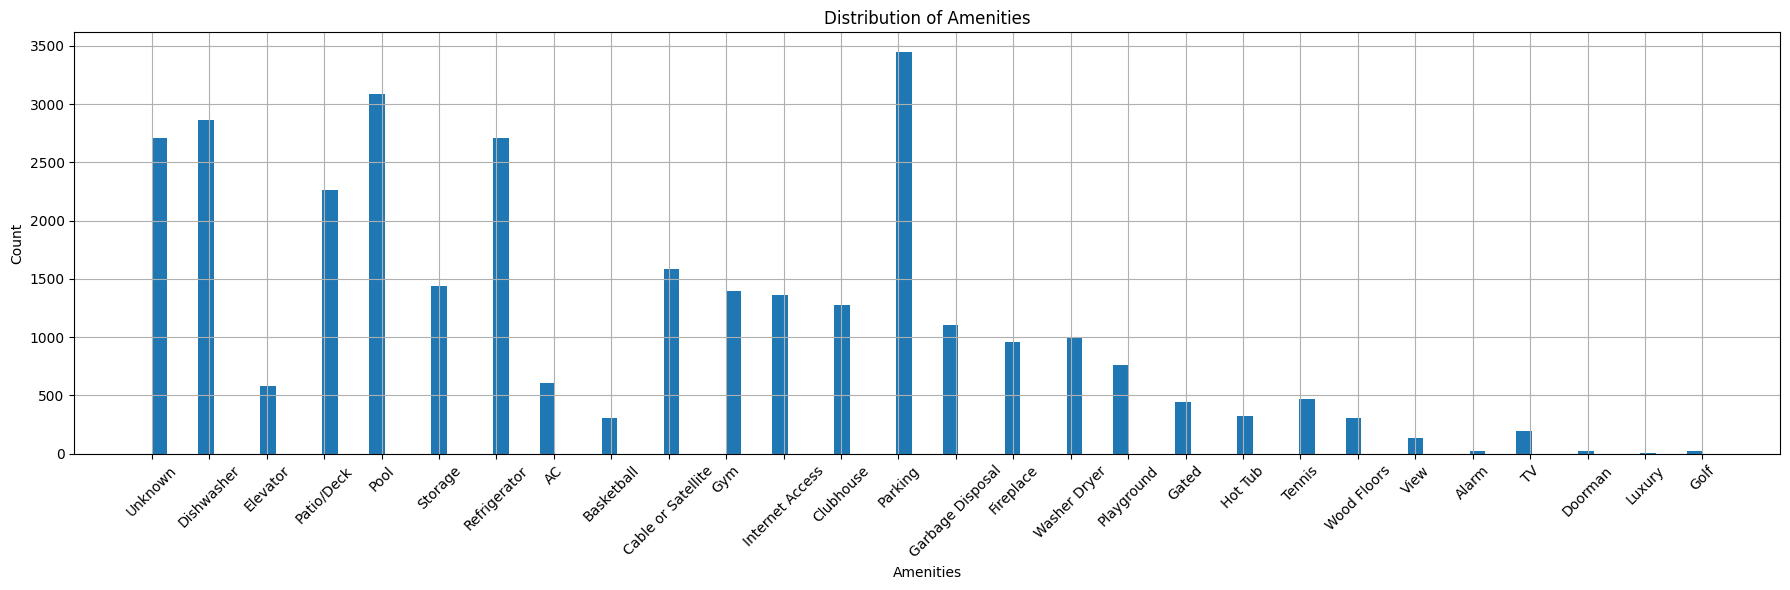

In [538]:
def plot_amenities_distribution(amenties: pd.Series) -> None:
    """
    Plot the distribution of the amenities in the dataframe.
    The function takes the following parameters:
    - df: the dataframe to plot
    - column: the column to plot
    - title: the title of the plot
    """
    plt.figure(figsize=(18, 6))
    data = amenties.explode()
    data.hist(bins=100)
    plt.title("Distribution of Amenities")
    plt.xlabel("Amenities")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


plot_amenities_distribution(rent["amenities"])

In [539]:
def multi_label_binarize_column(df: pd.DataFrame, column: str) -> pd.DataFrame:
    """
    Multi-label binarize a given column in the dataframe.
    The column is expected to contain lists of values.
    The function returns the dataframe with the multi-label binarized column.
    """
    df = df.copy()

    mlb = MultiLabelBinarizer(sparse_output=False)

    encoded = mlb.fit_transform(df[column])
    encoded_df = pd.DataFrame(encoded, columns=mlb.classes_, index=df.index)
    df = df.join(encoded_df)
    df = df.drop(columns=column)
    return df

In [540]:
rent = multi_label_binarize_column(rent, column="amenities")
rent.head()

,id,bathrooms,bedrooms,price,square_feet,pets_allowed_Cats,"pets_allowed_Cats,Dogs",pets_allowed_Dogs,pets_allowed_No,state_AK,...,Playground,Pool,Refrigerator,Storage,TV,Tennis,Unknown,View,Washer Dryer,Wood Floors
0,5668626833,1.0,0.0,1390,107,0.0,0.0,0.0,1.0,0.0,...,0,0,0,0,0,0,1,0,0,0
1,5659918074,1.0,0.0,925,116,0.0,0.0,0.0,1.0,0.0,...,0,0,0,0,0,0,1,0,0,0
2,5667891676,1.0,0.0,2475,130,0.0,0.0,0.0,1.0,0.0,...,0,1,0,1,0,0,0,0,0,0
3,5668610290,1.0,0.0,1495,138,0.0,0.0,0.0,1.0,0.0,...,0,0,1,0,0,0,0,0,0,0
4,5664571820,1.0,0.0,1695,190,0.0,0.0,0.0,1.0,0.0,...,0,0,1,0,0,0,0,0,0,0


### Adding poi(point of interest) count

In [541]:
poi_count = pd.read_parquet(poi_count_path)
poi_count

,id,tag,count,type
0,5668626895,pub,4,amenity
1,5668626895,restaurant,28,amenity
2,5668626895,fast_food,9,amenity
3,5668626895,museum,1,tourism
4,5668626895,bar,13,amenity
...,...,...,...,...
56945,5668662559,music_school,1,amenity
56946,5668662559,cinema,3,amenity
56947,5668662559,dancing_school,1,amenity
56948,5668662559,prep_school,2,amenity


In [542]:
poi_count.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56950 entries, 0 to 56949
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      56950 non-null  object
 1   tag     56950 non-null  object
 2   count   56950 non-null  int64 
 3   type    56950 non-null  object
dtypes: int64(1), object(3)
memory usage: 1.7+ MB


In [543]:
poi_count.describe()

,count
count,56950.000000
mean,5.074732
std,12.257293
min,1.000000
25%,1.000000
50%,2.000000
75%,5.000000
max,585.000000


In [544]:
poi_count[["tag"]].describe()

,tag
count,56950
unique,55
top,school
freq,7870


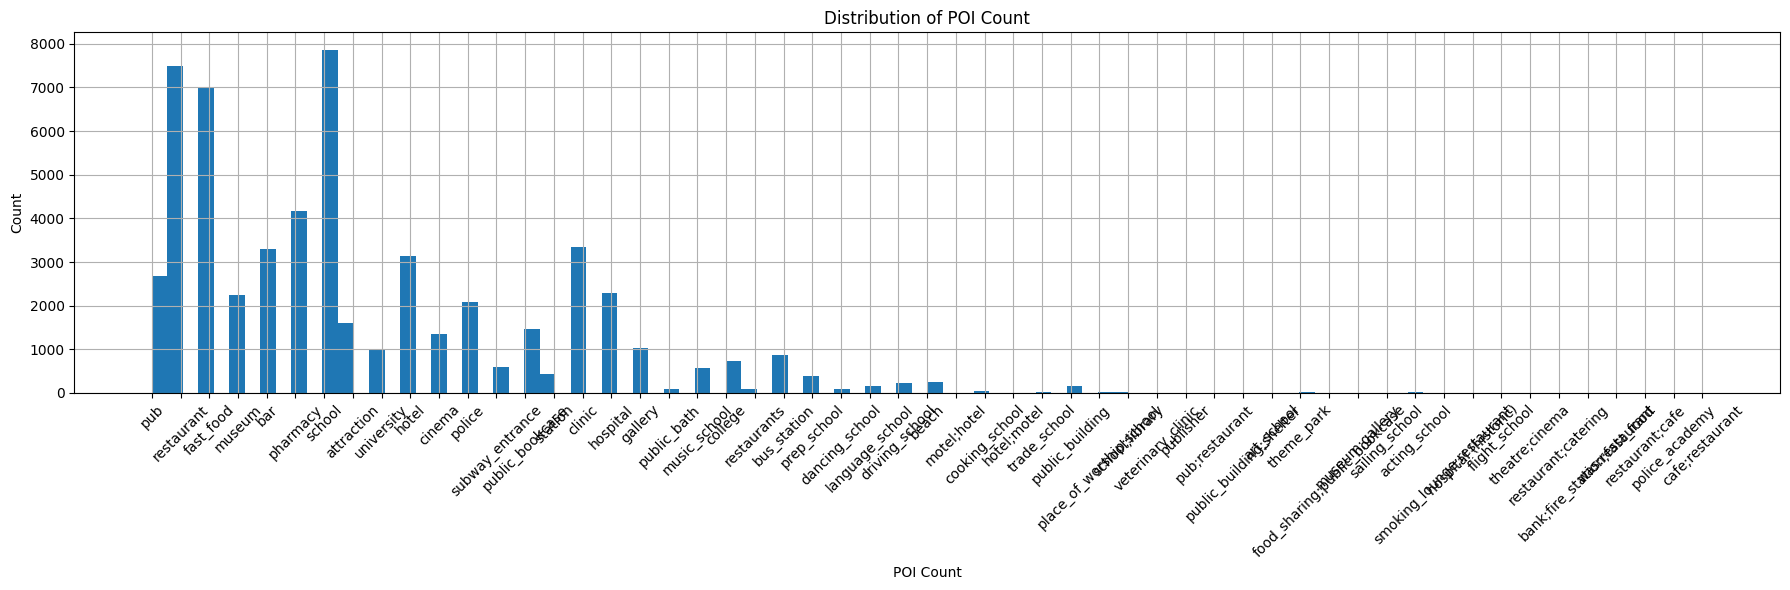

In [545]:
poi_count[["tag", "count"]].groupby("tag").count().sort_values(
    by="tag", ascending=False
)


def plot_poi_distribution(poi_count: pd.DataFrame) -> None:
    """
    Plot the distribution of the POI count in the dataframe.
    The function takes the following parameters:
    - df: the dataframe to plot
    - column: the column to plot
    - title: the title of the plot
    """
    plt.figure(figsize=(18, 6))
    data = poi_count["tag"]
    data.hist(bins=100)
    plt.title("Distribution of POI Count")
    plt.xlabel("POI Count")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


plot_poi_distribution(poi_count)

In [546]:
poi_pivot_table = poi_count.pivot_table(
    index="id",
    columns="tag",
    values="count",
    aggfunc="sum",  # or "first" depending on your data
    fill_value=0,
)

# Optionally: Rename columns to include "_count" suffix
poi_pivot_table.columns = [f"{col}_count" for col in poi_pivot_table.columns]

# Reset index if you want `id` as a column
poi_pivot_table

,acting_school_count,art_school_count,attraction_count,bank;fire_station;fast_food_count,bar_count,beach_count,bus_station_count,cafe;restaurant_count,cinema_count,clinic_count,...,school;library_count,smoking_lounge;restaurant_count,station_count,subway_entrance_count,theatre;cinema_count,theme_park_count,trade_school_count,university_count,veterinary_clinic_count,was:restaurant_count
id,,,,,,,,,,,,,,,,,,,,,
5508654087,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5508654149,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
5508654460,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5508654607,0,0,2,0,19,0,0,0,1,1,...,0,0,0,7,0,0,0,2,0,0
5508654638,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5668643363,0,0,0,0,0,0,0,0,0,3,...,0,0,0,0,0,0,0,0,0,0
5668643383,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
5668643398,0,0,0,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [547]:
rent_with_poi = pd.merge(
    rent,
    poi_pivot_table,
    left_on=["id"],
    right_index=True,
    how="left",
)

# Fill missing values in the new columns with 0
new_poi_amenities = rent_with_poi.columns.difference(rent.columns).tolist()
rent_with_poi[new_poi_amenities] = rent_with_poi[new_poi_amenities].fillna(0)
rent_with_poi

,id,bathrooms,bedrooms,price,square_feet,pets_allowed_Cats,"pets_allowed_Cats,Dogs",pets_allowed_Dogs,pets_allowed_No,state_AK,...,school;library_count,smoking_lounge;restaurant_count,station_count,subway_entrance_count,theatre;cinema_count,theme_park_count,trade_school_count,university_count,veterinary_clinic_count,was:restaurant_count
0,5668626833,1.0,0.0,1390,107,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,4.0,0.0,0.0,0.0,1.0,0.0,0.0
1,5659918074,1.0,0.0,925,116,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,9.0,0.0,0.0,0.0,1.0,0.0,0.0
2,5667891676,1.0,0.0,2475,130,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,14.0,108.0,0.0,0.0,0.0,4.0,0.0,0.0
3,5668610290,1.0,0.0,1495,138,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5664571820,1.0,0.0,1695,190,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8484,5668629192,2.0,3.0,2000,1574,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8485,5668624391,2.0,3.0,1549,1574,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8486,5664596429,2.5,2.0,1700,1575,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8487,5664576263,2.0,3.0,1425,1575,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


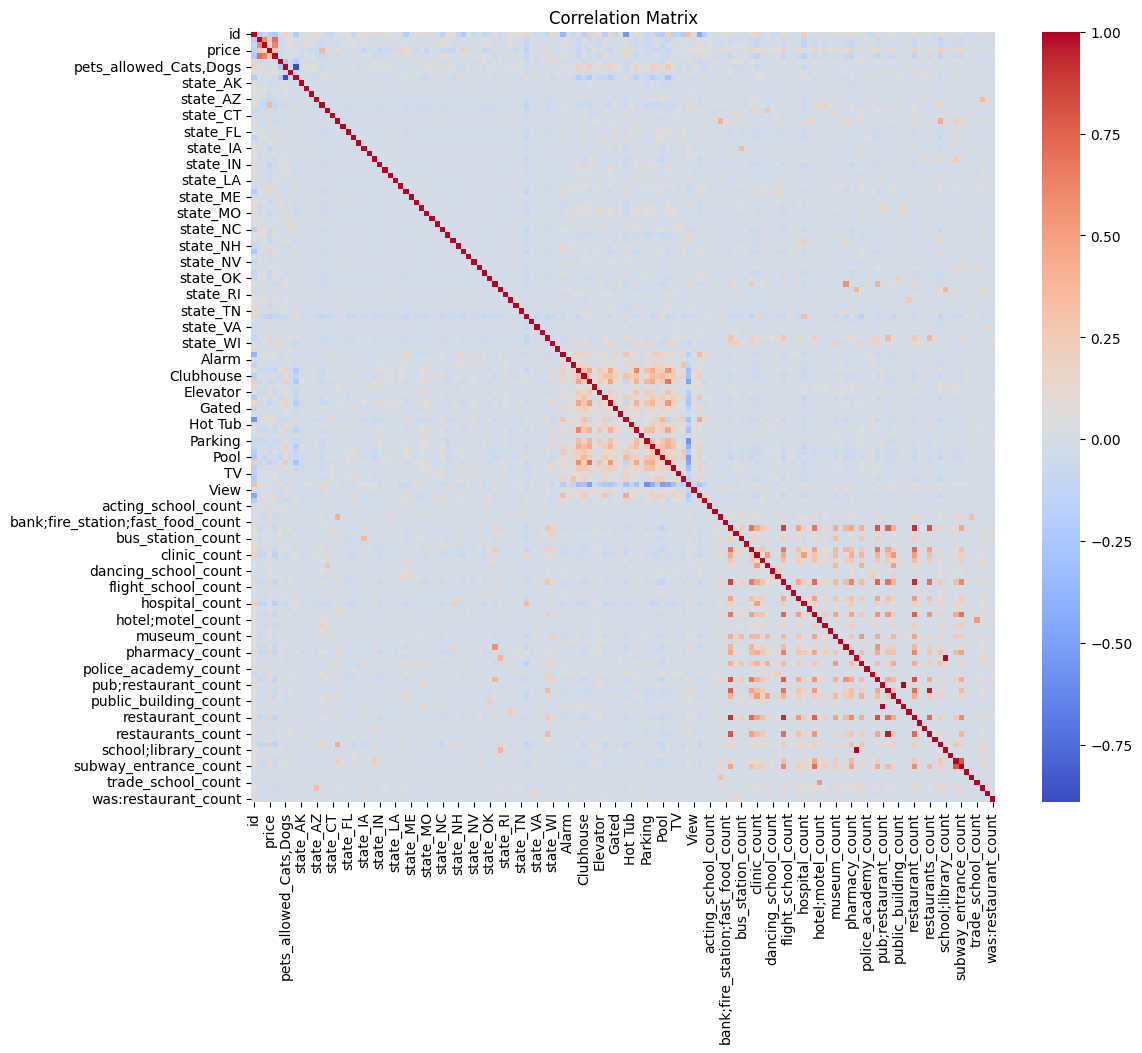

In [548]:
# Compute the correlation matrix
corr_matrix = rent_with_poi.corr()

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False, fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

Text(0, 0.5, 'Features')

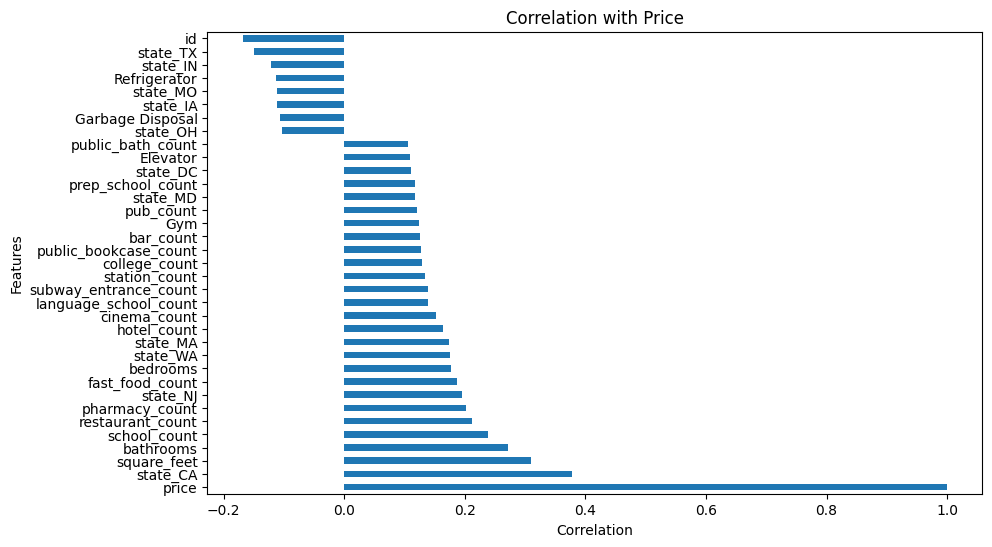

In [549]:
sorted_price_correlation = corr_matrix["price"].sort_values(ascending=False)
sorted_price_correlation[sorted_price_correlation.abs() > 0.1].plot(
    kind="barh", figsize=(10, 6)
)
plt.title("Correlation with Price")
plt.xlabel("Correlation")
plt.ylabel("Features")

In [550]:
rent_with_poi

,id,bathrooms,bedrooms,price,square_feet,pets_allowed_Cats,"pets_allowed_Cats,Dogs",pets_allowed_Dogs,pets_allowed_No,state_AK,...,school;library_count,smoking_lounge;restaurant_count,station_count,subway_entrance_count,theatre;cinema_count,theme_park_count,trade_school_count,university_count,veterinary_clinic_count,was:restaurant_count
0,5668626833,1.0,0.0,1390,107,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,4.0,0.0,0.0,0.0,1.0,0.0,0.0
1,5659918074,1.0,0.0,925,116,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,9.0,0.0,0.0,0.0,1.0,0.0,0.0
2,5667891676,1.0,0.0,2475,130,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,14.0,108.0,0.0,0.0,0.0,4.0,0.0,0.0
3,5668610290,1.0,0.0,1495,138,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5664571820,1.0,0.0,1695,190,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8484,5668629192,2.0,3.0,2000,1574,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8485,5668624391,2.0,3.0,1549,1574,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8486,5664596429,2.5,2.0,1700,1575,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8487,5664576263,2.0,3.0,1425,1575,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [551]:
rent_with_poi.columns.tolist()

['id',
 'bathrooms',
 'bedrooms',
 'price',
 'square_feet',
 'pets_allowed_Cats',
 'pets_allowed_Cats,Dogs',
 'pets_allowed_Dogs',
 'pets_allowed_No',
 'state_AK',
 'state_AL',
 'state_AR',
 'state_AZ',
 'state_CA',
 'state_CO',
 'state_CT',
 'state_DC',
 'state_DE',
 'state_FL',
 'state_GA',
 'state_HI',
 'state_IA',
 'state_ID',
 'state_IL',
 'state_IN',
 'state_KS',
 'state_KY',
 'state_LA',
 'state_MA',
 'state_MD',
 'state_ME',
 'state_MI',
 'state_MN',
 'state_MO',
 'state_MS',
 'state_MT',
 'state_NC',
 'state_ND',
 'state_NE',
 'state_NH',
 'state_NJ',
 'state_NM',
 'state_NV',
 'state_NY',
 'state_OH',
 'state_OK',
 'state_OR',
 'state_PA',
 'state_RI',
 'state_SC',
 'state_SD',
 'state_TN',
 'state_TX',
 'state_UT',
 'state_VA',
 'state_VT',
 'state_WA',
 'state_WI',
 'state_WV',
 'AC',
 'Alarm',
 'Basketball',
 'Cable or Satellite',
 'Clubhouse',
 'Dishwasher',
 'Doorman',
 'Elevator',
 'Fireplace',
 'Garbage Disposal',
 'Gated',
 'Golf',
 'Gym',
 'Hot Tub',
 'Internet Acces

In [552]:
# rent_with_poi.to_csv("rent_with_poi.csv", index=False)

In [553]:
rent_with_poi["hospital_count"] = (
    rent_with_poi["hospital_count"] + rent_with_poi["hospital (historic)_count"]
)
rent_with_poi.drop(columns=["hospital (historic)_count"], inplace=True)

In [554]:
rent_with_poi["hotel_count"] = (
    rent_with_poi["hotel_count"]
    + rent_with_poi["hotel;motel_count"]
    + rent_with_poi["motel;hotel_count"]
)
rent_with_poi.drop(columns=["hotel;motel_count"], inplace=True)
rent_with_poi.drop(columns=["motel;hotel_count"], inplace=True)

In [555]:
rent_with_poi["museum_count"] = (
    rent_with_poi["museum_count"] + rent_with_poi["museum;gallery_count"]
)
rent_with_poi.drop(columns=["museum;gallery_count"], inplace=True)

In [556]:
rent_with_poi["pub;restaurant_count"] = (
    rent_with_poi["pub_count"]
    + rent_with_poi["pub;restaurant_count"]
    + rent_with_poi["restaurant_count"]
)
(
    +rent_with_poi["restaurant;catering_count"]
    + rent_with_poi["smoking_lounge;restaurant_count"]
)
rent_with_poi.drop(
    columns=[
        "pub_count",
        "restaurant_count",
        "restaurant;catering_count",
        "smoking_lounge;restaurant_count",
    ],
    inplace=True,
)

In [557]:
school_cols = [
    "school;library_count",
    "art_school_count",
    "prep_school_count",
    "music_school_count",
    "acting_school_count",
    "cooking_school_count",
    "flight_school_count",
    "language_school_count",
    "sailing_school_count",
    "trade_school_count",
    "dancing_school_count",
    "driving_school_count",
]

rent_with_poi["school_count"] = rent_with_poi[["school_count"] + school_cols].sum(
    axis=1
)

rent_with_poi.drop(columns=school_cols, inplace=True)

In [558]:
rent_with_poi

,id,bathrooms,bedrooms,price,square_feet,pets_allowed_Cats,"pets_allowed_Cats,Dogs",pets_allowed_Dogs,pets_allowed_No,state_AK,...,restaurant;cafe_count,restaurants_count,school_count,station_count,subway_entrance_count,theatre;cinema_count,theme_park_count,university_count,veterinary_clinic_count,was:restaurant_count
0,5668626833,1.0,0.0,1390,107,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,4.0,1.0,4.0,0.0,0.0,1.0,0.0,0.0
1,5659918074,1.0,0.0,925,116,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,8.0,0.0,9.0,0.0,0.0,1.0,0.0,0.0
2,5667891676,1.0,0.0,2475,130,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,18.0,14.0,108.0,0.0,0.0,4.0,0.0,0.0
3,5668610290,1.0,0.0,1495,138,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,13.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0
4,5664571820,1.0,0.0,1695,190,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,13.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8484,5668629192,2.0,3.0,2000,1574,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8485,5668624391,2.0,3.0,1549,1574,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8486,5664596429,2.5,2.0,1700,1575,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8487,5664576263,2.0,3.0,1425,1575,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [559]:
rent_with_poi["police_count;police_academy_count"] = (
    rent_with_poi["police_count"] + rent_with_poi["police_academy_count"]
)
rent_with_poi.drop(columns=["police_count"], inplace=True)
rent_with_poi.drop(columns=["police_academy_count"], inplace=True)

In [560]:
rent_with_poi.drop(columns=["college_count"], inplace=True)

In [561]:
rent_with_poi["clinic_count"] = rent_with_poi["veterinary_clinic_count"] = (
    rent_with_poi["clinic_count"]
)
rent_with_poi.drop(columns=["veterinary_clinic_count"], inplace=True)

In [562]:
rent_with_poi.drop(columns=["id"], inplace=True)

## Feature engineering

#### Adiciona features com base nas amenities e POI

In [563]:
# 1. Identificar todas as colunas que terminam com 'count'
poi_columns = [col for col in rent_with_poi.columns if col.endswith("_count")]

# 2. Criar nova coluna com a soma de todos os POIs
rent_with_poi["total_poi_count"] = rent_with_poi[poi_columns].sum(axis=1)
# 3. Criar nova coluna com a soma de POIs essenciais
# Only sum columns that exist in the DataFrame
essential_cols = [
    col
    for col in [
        "hospital_count",
        "clinic_count",
        "pharmacy_count",
        "police_count",
        "school_count",
    ]
    if col in rent_with_poi.columns
]

rent_with_poi["essential_poi_count"] = rent_with_poi[essential_cols].sum(axis=1)

In [564]:
# Soma de todos os POIs em 1km (já existente como 'total_poi_count')
rent_with_poi["poi_density"] = rent_with_poi.filter(regex="_count$").sum(axis=1)

In [565]:
essential_pois = [
    "hospital_count",
    "clinic_count",
    "pharmacy_count",
    "police_count",
    "school_count",
]
existing_essential_pois = [
    col for col in essential_pois if col in rent_with_poi.columns
]
rent_with_poi["essential_poi_count"] = rent_with_poi[existing_essential_pois].sum(
    axis=1
)

# POIs de lazer
leisure_pois = [
    "restaurant_count",
    "pub_count",
    "cinema_count",
    "museum_count",
    "park_count",
]
existing_leisure_pois = [col for col in leisure_pois if col in rent_with_poi.columns]
rent_with_poi["leisure_poi_count"] = rent_with_poi[existing_leisure_pois].sum(axis=1)

In [566]:
# Densidade de amenities por área
amenity_cols = [
    "AC",
    "Alarm",
    "Basketball",
    "Cable or Satellite",
    "Clubhouse",
    "Dishwasher",
    "Doorman",
    "Elevator",
    "Fireplace",
    "Garbage Disposal",
    "Gated",
    "Golf",
    "Gym",
    "Hot Tub",
    "Internet Access",
    "Luxury",
    "Parking",
    "Patio/Deck",
    "Playground",
    "Pool",
    "Refrigerator",
    "Storage",
    "TV",
    "Tennis",
    "View",
    "Washer Dryer",
    "Wood Floors",
]

rent_with_poi["amenity_density"] = (
    rent_with_poi[amenity_cols].sum(axis=1) / rent_with_poi["square_feet"]
)
rent_with_poi["amenity_density"] = rent_with_poi["amenity_density"].replace(
    [np.inf, -np.inf], 0
)

In [567]:
# Score de luxo
luxury_features = ["Luxury", "Gym", "Pool", "Doorman", "Gated", "Elevator"]
rent_with_poi["luxury_score"] = rent_with_poi[luxury_features].sum(axis=1)

# Qualidade da cozinha
kitchen_features = ["Dishwasher", "Refrigerator", "Garbage Disposal"]
rent_with_poi["kitchen_quality"] = rent_with_poi[kitchen_features].sum(axis=1)

# Espaço externo
outdoor_features = ["Patio/Deck", "Pool", "View"]
rent_with_poi["outdoor_space"] = rent_with_poi[outdoor_features].sum(axis=1)

In [568]:
def drop_sparse_count_columns(df: pd.DataFrame, threshold: float = 0.01) -> None:
    """
    Remove inplace colunas que terminam com 'count' e têm menos de `threshold` (default 1%)
    de valores diferentes de zero, exceto 'beach_count'.
    """
    count_cols = [
        col for col in df.columns if col.endswith("count") and col != "beach_count"
    ]

    cols_to_drop = []
    for col in count_cols:
        non_zero_ratio = (df[col] != 0).mean()
        if non_zero_ratio < threshold:
            cols_to_drop.append(col)

    df.drop(columns=cols_to_drop, inplace=True)


drop_sparse_count_columns(rent_with_poi)

## Traning model

In [569]:
X = rent_with_poi.drop(columns=[TARGET])
y = rent_with_poi[TARGET]

In [570]:
# Clusteriza com base nos estados
# Recupera coluna original dos estados
state_columns = [col for col in X.columns if col.startswith("state_")]
estado_por_linha = X[state_columns].idxmax(axis=1).str.replace("state_", "")

# Conta quantas vezes cada estado aparece
estado_counts = estado_por_linha.value_counts()

# Filtra para manter apenas estados com 2 ou mais amostras
estados_validos = estado_counts[estado_counts >= 2].index
filtro = estado_por_linha.isin(estados_validos)

# Aplica o filtro a X, y e à coluna de estado
X_filtrado = X[filtro]
y_filtrado = y[filtro]
estado_filtrado = estado_por_linha[filtro]

# Agora faz o split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X_filtrado,
    y_filtrado,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=estado_filtrado,
)

In [571]:
rent_with_poi

,bathrooms,bedrooms,price,square_feet,pets_allowed_Cats,"pets_allowed_Cats,Dogs",pets_allowed_Dogs,pets_allowed_No,state_AK,state_AL,...,university_count,police_count;police_academy_count,total_poi_count,essential_poi_count,poi_density,leisure_poi_count,amenity_density,luxury_score,kitchen_quality,outdoor_space
0,1.0,0.0,1390,107,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,2.0,79.0,8.0,166.0,1.0,0.000000,0,0,0
1,1.0,0.0,925,116,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,2.0,431.0,26.0,888.0,5.0,0.000000,0,0,0
2,1.0,0.0,2475,130,0.0,0.0,0.0,1.0,0.0,0.0,...,4.0,3.0,922.0,47.0,1891.0,10.0,0.038462,2,1,2
3,1.0,0.0,1495,138,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,102.0,21.0,225.0,3.0,0.007246,0,1,0
4,1.0,0.0,1695,190,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,102.0,21.0,225.0,3.0,0.005263,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8484,2.0,3.0,2000,1574,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,16.0,7.0,39.0,0.0,0.000000,0,0,0
8485,2.0,3.0,1549,1574,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,3.0,0.0,6.0,0.0,0.001906,0,3,0
8486,2.5,2.0,1700,1575,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,3.0,0.0,0.000635,0,0,0
8487,2.0,3.0,1425,1575,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0,0,0


In [572]:
# Define o modelo base
rfc = RandomForestRegressor(random_state=RANDOM_SEED, n_jobs=-1)

# Testa com RandomizedSearchCV para ter uma maior controle dos hiperparâmetros e ser mais performático
param_dist = {
    "n_estimators": [50, 100, 150, 200],
    "max_depth": [5, 10, 20, None],
    "min_samples_split": [2, 4, 6, 8, 10],
    "min_samples_leaf": [1, 2, 3, 4],
    "max_features": ["sqrt", "log2"],
}

# RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=rfc,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring="r2",
    verbose=2,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)

In [573]:
# Executa a busca nos dados de treino
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


         rmse         mae        r2           mse
0  271.267913  202.895948  0.650054  73586.280465


KeyError: "['latitude', 'longitude'] not in index"

In [ ]:
# Resultados
print("Melhores hiperparâmetros encontrados:")
print(random_search.best_params_)

print("Melhor score (cross-validation):")
print(random_search.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Melhores hiperparâmetros encontrados:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}
Melhor score (cross-validation):
0.773940256506465


In [ ]:
y_pred = random_search.best_estimator_.predict(X_test)

In [ ]:
def evaluate_model(y_test: pd.Series, y_pred: pd.Series) -> pd.DataFrame:
    """
    Evaluate the model using RMSE, MAE, MSE and R²
    """
    rmse = root_mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)

    return pd.DataFrame(
        {
            "rmse": [rmse],
            "mae": [mae],
            "r2": [r2],
            "mse": [mse],
        }
    )

In [ ]:
result = evaluate_model(y_test, y_pred)
result

,rmse,mae,r2,mse
0,209.301217,154.210483,0.791672,43806.999264


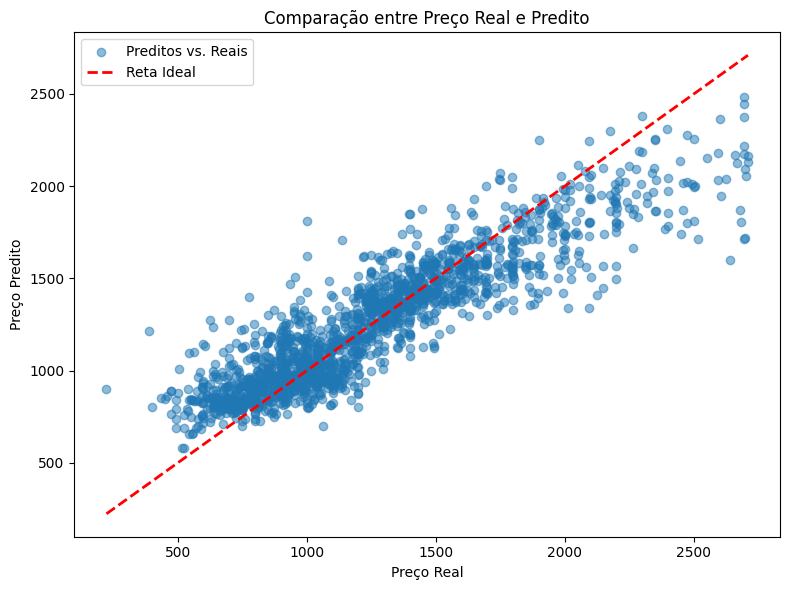

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, label="Preditos vs. Reais")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    lw=2,
    label="Reta Ideal",
)
plt.xlabel("Preço Real")
plt.ylabel("Preço Predito")
plt.title("Comparação entre Preço Real e Predito")
plt.legend()
plt.tight_layout()
plt.show()

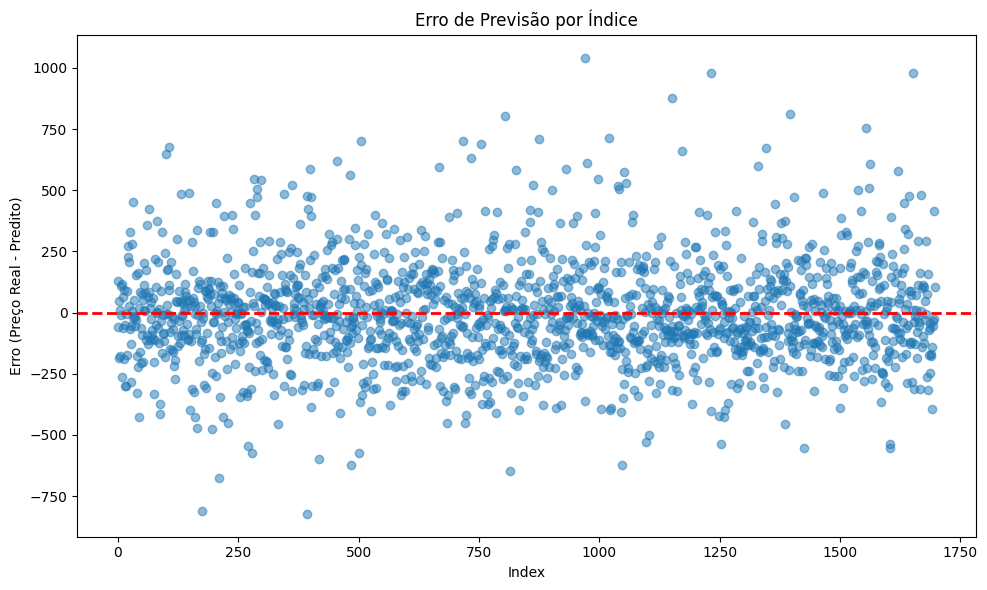

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(np.arange(len(y_test)), y_test - y_pred, marker="o", linestyle="", alpha=0.5)
plt.axhline(
    0, color="red", linestyle="--", linewidth=2
)  # reta vermelha pontilhada em y=0
plt.xlabel("Index")
plt.ylabel("Erro (Preço Real - Predito)")
plt.title("Erro de Previsão por Índice")
plt.tight_layout()
plt.show()

In [ ]:
kf = KFold(random_state=RANDOM_SEED, shuffle=True, n_splits=5)

cross_val_scores = cross_val_score(
    RandomForestRegressor(random_state=RANDOM_SEED),
    X_train,
    y_train,
    cv=kf,
    scoring="neg_mean_squared_error",
)

In [ ]:
cross_val_scores

array([-33841.82466748, -33952.70090823, -31233.82169137, -32948.98800495,
       -33521.91225733])

In [ ]:
# Compute cross-validation scores (negative MSE), take absolute value, then sqrt for RMSE
sqrt_cross_val_scores = np.sqrt(np.abs(cross_val_scores))
sqrt_cross_val_scores

array([183.96147604, 184.26258684, 176.73093021, 181.51856105,
       183.08990212])

In [ ]:
sqrt_cross_val_scores.mean()

np.float64(181.912691250176)

In [ ]:
rent_with_poi

,bathrooms,bedrooms,price,square_feet,pets_allowed_Cats,"pets_allowed_Cats,Dogs",pets_allowed_Dogs,pets_allowed_No,state_AK,state_AL,...,police_count;police_academy_count,cluster,total_poi_count,essential_poi_count,poi_density,leisure_poi_count,amenity_density,luxury_score,kitchen_quality,outdoor_space
0,1.0,0.0,1390,107,0.0,0.0,0.0,1.0,0.0,0.0,...,2.0,2.0,79.0,8.0,166.0,1.0,0.000000,0,0,0
1,1.0,0.0,925,116,0.0,0.0,0.0,1.0,0.0,0.0,...,2.0,2.0,431.0,26.0,888.0,5.0,0.000000,0,0,0
2,1.0,0.0,2475,130,0.0,0.0,0.0,1.0,0.0,0.0,...,3.0,0.0,922.0,47.0,1891.0,10.0,0.038462,2,1,2
3,1.0,0.0,1495,138,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,2.0,102.0,21.0,225.0,3.0,0.007246,0,1,0
4,1.0,0.0,1695,190,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,102.0,21.0,225.0,3.0,0.005263,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8484,2.0,3.0,2000,1574,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,4.0,16.0,7.0,39.0,0.0,0.000000,0,0,0
8485,2.0,3.0,1549,1574,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,4.0,3.0,0.0,6.0,0.0,0.001906,0,3,0
8486,2.5,2.0,1700,1575,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,4.0,1.0,1.0,3.0,0.0,0.000635,0,0,0
8487,2.0,3.0,1425,1575,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,4.0,0.0,0.0,0.0,0.0,0.000000,0,0,0
